# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from GCN import GCN
from GraphSAGE import GraphSAGE
from GAT import GAT
from torch_geometric.datasets import PPI
from torch_geometric.loader import DataLoader
import numpy as np
import random
from sklearn.metrics import f1_score, accuracy_score


/home/hice1/pmaji3/scratch/gnn02/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

cuda


In [4]:
args = {
      'device': device,
      'num_layers': 3,
      'hidden_dim': 256,
      'dropout': 0.3,
      'lr': 0.01,
      'epochs': 100,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 0,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 2,
      'val_batch_size': 2,
      #heads for GAT
      'heads': 2
  }

# Dataset

In [5]:
train_dataset = PPI(root='tmp/PPI', split='train')
val_dataset = PPI(root='tmp/PPI', split='val')
test_dataset = PPI(root='tmp/PPI', split='test')

Extracting tmp/PPI/ppi.zip
Processing...
Done!


In [6]:
num_features = train_dataset.num_features
num_classes = train_dataset.num_classes

print(f"Number of graphs in training dataset: {len(train_dataset)}")
print(f"Number of graphs in val dataset: {len(val_dataset)}")
print(f"Number of graphs in test dataset: {len(test_dataset)}")

print(f"Number of features for each node: {num_features}")
print(f"Number of num_classes : {num_classes}")

for i in range(len(train_dataset)):
    print(f"Number of nodes in training dataset: {i}:", train_dataset[i])

for i in range(len(val_dataset)):
    print(f"Number of nodes in val_dataset: {i}:", val_dataset[i])

for i in range(len(test_dataset)):
    print(f"Number of nodes in test_dataset dataset: {i}:", test_dataset[i])


Number of graphs in training dataset: 20
Number of graphs in val dataset: 2
Number of graphs in test dataset: 2
Number of features for each node: 50
Number of num_classes : 121
Number of nodes in training dataset: 0: Data(x=[1767, 50], edge_index=[2, 32318], y=[1767, 121])
Number of nodes in training dataset: 1: Data(x=[1377, 50], edge_index=[2, 29704], y=[1377, 121])
Number of nodes in training dataset: 2: Data(x=[2263, 50], edge_index=[2, 59644], y=[2263, 121])
Number of nodes in training dataset: 3: Data(x=[2339, 50], edge_index=[2, 65430], y=[2339, 121])
Number of nodes in training dataset: 4: Data(x=[1578, 50], edge_index=[2, 36162], y=[1578, 121])
Number of nodes in training dataset: 5: Data(x=[1021, 50], edge_index=[2, 18216], y=[1021, 121])
Number of nodes in training dataset: 6: Data(x=[1823, 50], edge_index=[2, 44330], y=[1823, 121])
Number of nodes in training dataset: 7: Data(x=[2488, 50], edge_index=[2, 70390], y=[2488, 121])
Number of nodes in training dataset: 8: Data(x=

In [7]:
#For training, each batch is one graph
train_loader = DataLoader(train_dataset, batch_size = args['training_batch_size'], shuffle=True)
#For validation, each batch is a merge of 2 validation graphs
val_loader = DataLoader(val_dataset, batch_size= args['val_batch_size'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=args['test_batch_size'], shuffle=False)

# Train Function

In [8]:
def train(model, loader, optimizer, criterion):
    """
    one training epoch
    model -  GNN (GCNConv or GraphSAGE)
    loader - PyG DataLoader containing batches of graphs
    optimizer - algorithm that updates model weights (Adam, SGD, etc.)
    criterion - loss function (often BCEWithLogitsLoss for the PPI dataset)
    """
    #Training mode
    model.train()
    # Total loss across all batches
    total_loss = 0
    
    # Loop through the batches of graph
    # In case of PPI, each training batch has 1 graph
    # Loop runs 20 times during training
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        # x=[total_nodes_in_batch, num_features]
        # edge_index=[2, total_edges_in_batch]
        # out: [num_nodes, num_classes], num_class = 121 for PPI
        out = model(data.x, data.edge_index)
        loss = criterion(out, data.y)

        #Sum loss over all batches (i.e. all graphs)
        #data.num_graphs = 1 for batch_size = 1
        total_loss += loss.item() * data.num_graphs
        loss.backward()
        optimizer.step()
    
    return total_loss/len(loader.dataset)

# Test Function

In [9]:
def test(model, loader):
    #switch to evaluation mode
    model.eval()
    # ys: Ground Truth Labels, preds: model predictions across all batches
    ys, preds = [], []
    # for each data is a graph batch from PyTorch Geometric
    for data in loader:
        data = data.to(device)
        with torch.no_grad():
            #[num_nodes, num_classes]
            out = model(data.x, data.edge_index)
        # convert logits to binary predictions
        #pred = (out >0).float().cpu()
        pred = (torch.sigmoid(out) > 0.5).float()
        y = data.y.cpu()
        
        preds.append(pred)
        ys.append(y)
    
    # Merge all batches: batch1 nodes: 4000, batch2 nodes: 3500 -> 7500 nodes total
    y = torch.cat(ys, dim=0).cpu().numpy() 
    pred = torch.cat(preds, dim=0).cpu().numpy()
    #scikit-learn f1_score
    # if all the preds is zero, return 0
    f1 = f1_score(y, pred, average='micro', zero_division=0)
    acc = accuracy_score(y.flatten(), pred.flatten())
    return f1, acc
        

# Notes:
### BCEWithLogitsLoss because its a Multi-label classification
### In the PPI dataset, a protein can have multiple biological functions.

# Train and Evaluate

In [10]:
import time

In [11]:
def train_and_evaluate(model, train_loader, val_loader, test_loader, optimizer, scheduler, criterion, epochs=100):
    best_val_f1 = 0
    train_losses, val_f1s, val_accs, test_f1s, test_accs = [],[],[],[],[]
    training_time = 0

    for epoch in range(1, epochs+1):
        start_time = time.time()

        loss = train(model, train_loader, optimizer, criterion)
        
        if scheduler:
            scheduler.step()

        epoch_time = time.time() - start_time
        training_time += epoch_time

        val_f1, val_acc = test(model, val_loader)
        test_f1, test_acc = test(model, test_loader)

        train_losses.append(loss)
        val_f1s.append(val_f1)
        test_f1s.append(test_f1)
        val_accs.append(val_acc)
        test_accs.append(test_acc)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), 'best_model_gcn.pth')

        if epoch % 10 == 0:
            print(f"Epoch: {epoch:03d}, "
                f"Loss: {loss:.4f}, "
                f"Val F1: {val_f1:.4f},"
                f"Val Acc: {val_acc:.4f}, "
                f"Time: {epoch_time:.2f}s"
                )


    model.load_state_dict(torch.load('best_model_gcn.pth', map_location=device))
    test_f1, test_acc = test(model, test_loader)
    print(f"Test F1: {test_f1:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    return model, train_losses, val_f1s, test_f1s, training_time

In [12]:
def build_optimizer(args, params):
    
    filter_fn = filter(lambda p : p.requires_grad, params)
    weight_decay = args['weight_decay']
    if args['opt'] == 'adam':
        optimizer = torch.optim.Adam(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    elif args['opt'] == 'sgd':
        optimizer = torch.optim.SGD(filter_fn, lr=args['lr'], momentum=0.95, weight_decay=weight_decay)
    elif args['opt'] == 'rmsprop':
        optimizer = torch.optim.RMSprop(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    elif args['opt'] == 'adagrad':
        optimizer = torch.optim.Adagrad(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    if args['opt_scheduler'] == 'none':
        return None, optimizer
    elif args['opt_scheduler'] == 'step':
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=args['opt_decay_step'], gamma=args['opt_decay_rate'])
    elif args['opt_scheduler'] == 'cos':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args['opt_restart'])
    return scheduler, optimizer

In [13]:
import matplotlib.pyplot as plt
def plot_results(results, title, label, ylabel):
    plt.figure(figsize=(3,2))
    epochs = range(1, len(results)+1)
    plt.plot(epochs, results, label = label)
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel(ylabel)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()

In [14]:
def gcn_run():
    model = GCN(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.BCEWithLogitsLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    print("Training GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        train_loader, 
        val_loader, 
        test_loader, 
        optimizer,
        scheduler, 
        criterion, 
        epochs=args["epochs"])
    print(training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GCN','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GCN','F1 Score')


Training GCN
Epoch: 010, Loss: 0.4687, Val F1: 0.5452,Val Acc: 0.7703, Time: 0.09s
Epoch: 020, Loss: 0.4411, Val F1: 0.6226,Val Acc: 0.7911, Time: 0.08s
Epoch: 030, Loss: 0.4313, Val F1: 0.5922,Val Acc: 0.7803, Time: 0.09s
Epoch: 040, Loss: 0.4245, Val F1: 0.6291,Val Acc: 0.7921, Time: 0.09s
Epoch: 050, Loss: 0.4188, Val F1: 0.5850,Val Acc: 0.8016, Time: 0.09s
Epoch: 060, Loss: 0.4148, Val F1: 0.5826,Val Acc: 0.7938, Time: 0.09s
Epoch: 070, Loss: 0.4147, Val F1: 0.6605,Val Acc: 0.7957, Time: 0.09s
Epoch: 080, Loss: 0.4100, Val F1: 0.6422,Val Acc: 0.8041, Time: 0.09s
Epoch: 090, Loss: 0.4061, Val F1: 0.6414,Val Acc: 0.8062, Time: 0.09s
Epoch: 100, Loss: 0.4058, Val F1: 0.6528,Val Acc: 0.7944, Time: 0.08s
Test F1: 0.6780
Test Accuracy: 0.8055
19.956100463867188


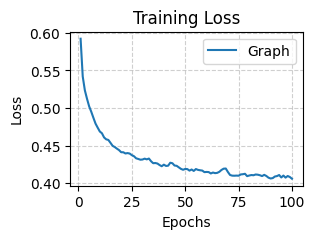

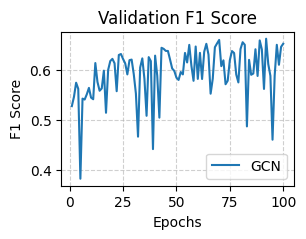

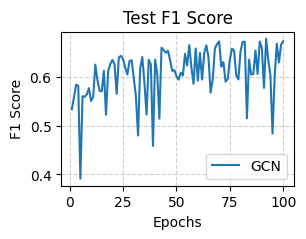

In [15]:
gcn_run()

In [16]:
def graphSage_run():
    model = GraphSAGE(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.BCEWithLogitsLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    print("Training GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        train_loader, 
        val_loader, 
        test_loader, 
        optimizer,
        scheduler, 
        criterion, 
        epochs=args["epochs"])
    print(training_time)

    plot_results(train_losses, 'Training Loss', 'GraphSAGE','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GraphSAGE','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GraphSAGE','F1 Score')


Training GCN
Epoch: 010, Loss: 0.3585, Val F1: 0.7469,Val Acc: 0.8590, Time: 0.07s
Epoch: 020, Loss: 0.3071, Val F1: 0.7969,Val Acc: 0.8791, Time: 0.07s
Epoch: 030, Loss: 0.2817, Val F1: 0.8333,Val Acc: 0.9044, Time: 0.07s
Epoch: 040, Loss: 0.2674, Val F1: 0.8461,Val Acc: 0.9102, Time: 0.07s
Epoch: 050, Loss: 0.2561, Val F1: 0.8571,Val Acc: 0.9162, Time: 0.07s
Epoch: 060, Loss: 0.2470, Val F1: 0.8617,Val Acc: 0.9186, Time: 0.07s
Epoch: 070, Loss: 0.2429, Val F1: 0.8634,Val Acc: 0.9198, Time: 0.07s
Epoch: 080, Loss: 0.2396, Val F1: 0.8712,Val Acc: 0.9243, Time: 0.07s
Epoch: 090, Loss: 0.2343, Val F1: 0.8698,Val Acc: 0.9244, Time: 0.07s
Epoch: 100, Loss: 0.2287, Val F1: 0.8580,Val Acc: 0.9131, Time: 0.07s
Test F1: 0.8961
Test Accuracy: 0.9393
7.472602605819702


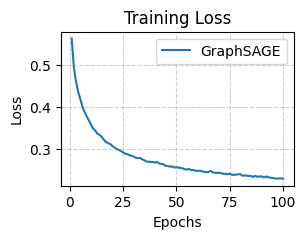

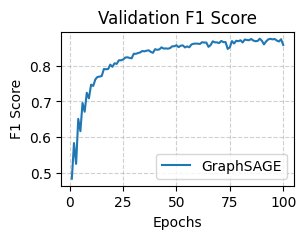

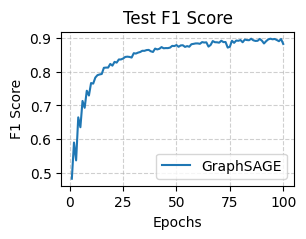

In [17]:
graphSage_run()

In [18]:
def gat_run():
    model = GAT(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'],
                heads=args['heads'],
                dropout=args['dropout']).to(device)
    criterion = torch.nn.BCEWithLogitsLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    print("Training GAT")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        train_loader, 
        val_loader, 
        test_loader, 
        optimizer,
        scheduler, 
        criterion, 
        epochs=args["epochs"])
    print(training_time)

    plot_results(train_losses, 'Training Loss', 'GAT','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GAT','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GAT','F1 Score')


Training GAT
Epoch: 010, Loss: 0.5473, Val F1: 0.4138,Val Acc: 0.7505, Time: 0.17s
Epoch: 020, Loss: 0.5322, Val F1: 0.4754,Val Acc: 0.7566, Time: 0.17s
Epoch: 030, Loss: 0.5078, Val F1: 0.4771,Val Acc: 0.7633, Time: 0.19s
Epoch: 040, Loss: 0.5007, Val F1: 0.4612,Val Acc: 0.7637, Time: 0.19s
Epoch: 050, Loss: 0.4937, Val F1: 0.4944,Val Acc: 0.7678, Time: 0.27s
Epoch: 060, Loss: 0.4889, Val F1: 0.5126,Val Acc: 0.7722, Time: 0.21s
Epoch: 070, Loss: 0.4870, Val F1: 0.4623,Val Acc: 0.7662, Time: 0.27s
Epoch: 080, Loss: 0.4837, Val F1: 0.5420,Val Acc: 0.7725, Time: 0.17s
Epoch: 090, Loss: 0.4810, Val F1: 0.4597,Val Acc: 0.7662, Time: 0.16s
Epoch: 100, Loss: 0.4781, Val F1: 0.4725,Val Acc: 0.7617, Time: 0.17s
Test F1: 0.5649
Test Accuracy: 0.7750
19.063448667526245


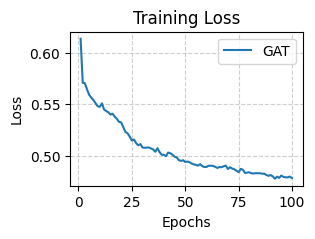

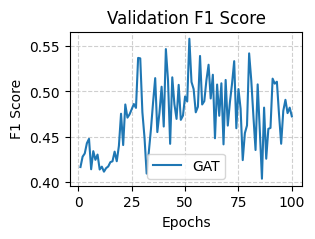

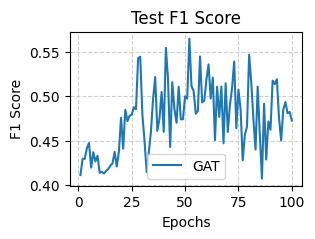

In [19]:
gat_run()